### Objective


### Problem Statement


### Data Overview


In [9]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


### import libraries


In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, LogisticRegression , Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Data Gathering


In [11]:
df = pd.read_csv(r"medical_insurance_regression.csv")
df

,age,sex,bmi,smoker,region,children,charges
0,21.000000,male,25.745000,no,northeast,2,3279.868550
1,36.976978,female,25.744165,yes,southeast,3,21454.494239
2,18.000000,male,30.030000,no,southeast,1,1720.353700
3,37.000000,male,30.676891,no,northeast,3,6801.437542
4,58.000000,male,32.010000,no,southeast,1,11946.625900
...,...,...,...,...,...,...,...
3625,48.820767,female,41.426984,no,northwest,4,10987.324964
3626,38.661977,female,26.202557,no,southeast,2,11735.844352
3627,56.000000,male,40.300000,no,southwest,0,10602.385000
3628,48.061207,female,34.930624,no,southeast,1,8976.140452


### Data Preprocessing


In [12]:
df.shape

(3630, 7)

In [13]:
df.size

25410

In [14]:
df.columns

Index(['age', 'sex', 'bmi', 'smoker', 'region', 'children', 'charges'], dtype='object')

In [15]:
df.index

RangeIndex(start=0, stop=3630, step=1)

In [16]:
df.axes

[RangeIndex(start=0, stop=3630, step=1),
 Index(['age', 'sex', 'bmi', 'smoker', 'region', 'children', 'charges'], dtype='object')]

In [17]:
df.dtypes

age         float64
sex          object
bmi         float64
smoker       object
region       object
children      int64
charges     float64
dtype: object

In [18]:
df.isna().sum() # checking of missing values

age         0
sex         0
bmi         0
smoker      0
region      0
children    0
charges     0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(679)

In [20]:
df.drop_duplicates(inplace=True)

### EDA


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2951 entries, 0 to 2951
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2951 non-null   float64
 1   sex       2951 non-null   object 
 2   bmi       2951 non-null   float64
 3   smoker    2951 non-null   object 
 4   region    2951 non-null   object 
 5   children  2951 non-null   int64  
 6   charges   2951 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 184.4+ KB


In [22]:
df.describe()

,age,bmi,children,charges
count,2951.000000,2951.000000,2951.000000,2951.000000
mean,38.972994,30.614864,2.498814,12847.623458
std,12.191312,5.412875,1.711947,10762.255653
min,18.000000,15.960000,0.000000,1121.873900
25%,29.000000,26.717292,1.000000,5701.034262
50%,39.296556,30.210000,3.000000,9523.978586
75%,48.559226,34.095907,4.000000,14831.372859
max,64.000000,53.130000,5.000000,63770.428010


<Axes: ylabel='charges'>

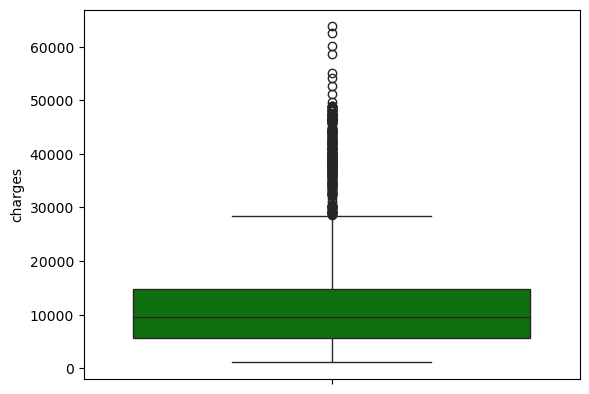

In [23]:
sns.boxplot(df["charges"], color = "green")

<Axes: >

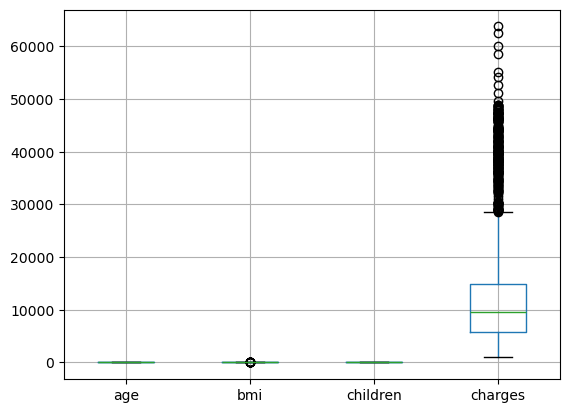

In [24]:
df.boxplot()

In [25]:
# univariate analysis
def Univariate_Continuous_Data_Analysis(col):
    print(f"Analysis of Column : {col}")
    print("-"*50)
     
    stats_list = []
    stats_df = pd.DataFrame()
    stats_list.append(df[col].mean())
    stats_list.append(df[col].median())
    stats_list.append(df[col].var())
    stats_list.append(df[col].std())
    stats_list.append(df[col].max() - df[col].min())
    #print(stats_list)

    print(f"Stats for a columns : {col}")
    stats_df = pd.DataFrame(stats_list,index = ["Mean", "Median", "Var", "std", "range"], columns = [col])
    print(stats_df)

    print("-"*50)
    

In [26]:
Univariate_Continuous_Data_Analysis("age")

Analysis of Column : age
--------------------------------------------------
Stats for a columns : age
               age
Mean     38.972994
Median   39.296556
Var     148.628087
std      12.191312
range    46.000000
--------------------------------------------------


In [27]:
Univariate_Continuous_Data_Analysis("bmi")

Analysis of Column : bmi
--------------------------------------------------
Stats for a columns : bmi
              bmi
Mean    30.614864
Median  30.210000
Var     29.299218
std      5.412875
range   37.170000
--------------------------------------------------


<Axes: xlabel='age', ylabel='Count'>

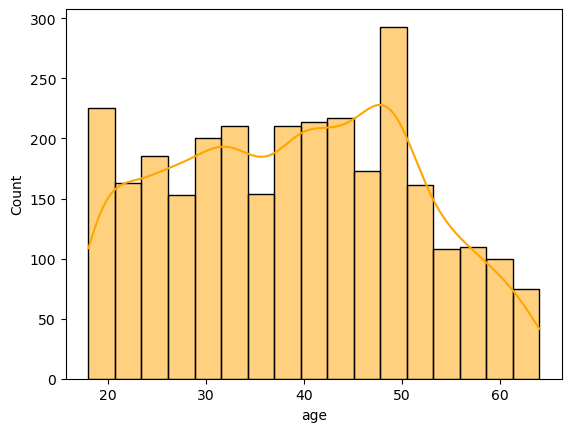

In [28]:
sns.histplot(df["age"], kde = True, color = "orange")

<Axes: xlabel='bmi', ylabel='Count'>

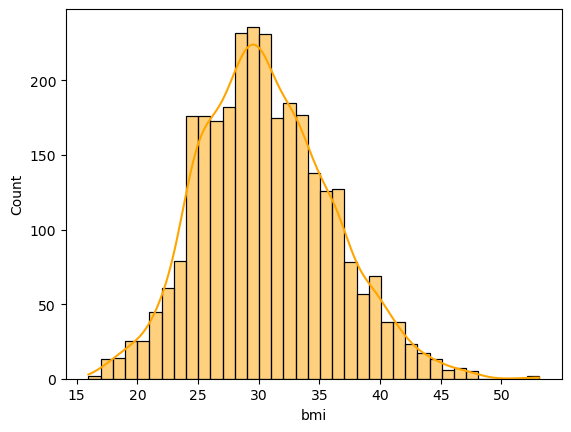

In [29]:
sns.histplot(df["bmi"], kde = True, color = "orange")

In [30]:
def Unvariate_visualization(col):
    print(f"Visualization for : {col}")
    plt.figure(figsize=(5, 5))
    fig, ax = plt.subplots(1,2)
    sns.histplot(df[col], color = "red", ax = ax[0])
    sns.kdeplot(df[col], fill = True, color = "Green",ax = ax[1])
    plt.tight_layout()

Visualization for : age


<Figure size 500x500 with 0 Axes>

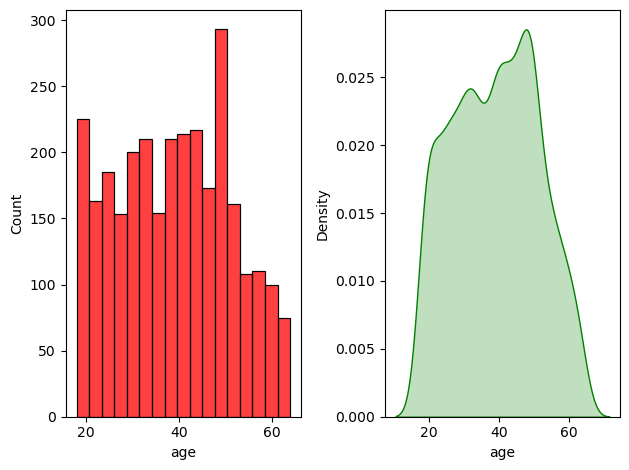

In [31]:
Unvariate_visualization("age")

Visualization for : bmi


<Figure size 500x500 with 0 Axes>

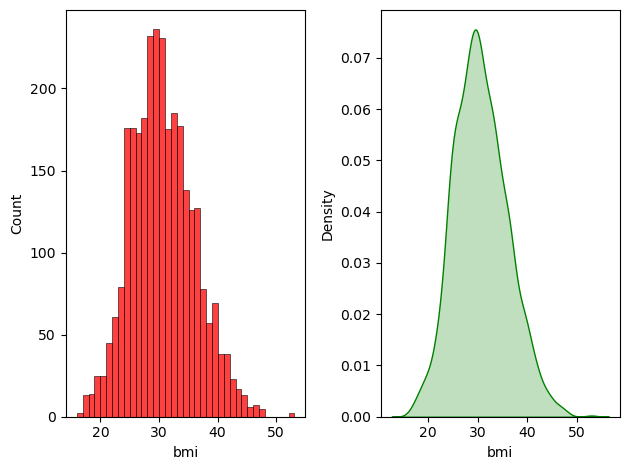

In [32]:
Unvariate_visualization("bmi")

In [33]:
def Categorical_Dat_Analysis(col):
    print(f"Analysis for column : {col}")
    print(f"No. Of Unique Values: {df[col].nunique()}")
    print(f"Unique Values : {df[col].unique()}")
    print(f"Value Count : {df[col].value_counts()}")
    print("-"*50)
    

In [34]:
Categorical_Dat_Analysis("smoker")

Analysis for column : smoker
No. Of Unique Values: 2
Unique Values : ['no' 'yes']
Value Count : smoker
no     2490
yes     461
Name: count, dtype: int64
--------------------------------------------------


In [35]:
Categorical_Dat_Analysis("children")

Analysis for column : children
No. Of Unique Values: 6
Unique Values : [2 3 1 4 5 0]
Value Count : children
0    502
2    494
3    493
5    493
4    491
1    478
Name: count, dtype: int64
--------------------------------------------------


In [36]:
Categorical_Dat_Analysis("region")

Analysis for column : region
No. Of Unique Values: 4
Unique Values : ['northeast' 'southeast' 'northwest' 'southwest']
Value Count : region
southeast    824
northwest    734
northeast    699
southwest    694
Name: count, dtype: int64
--------------------------------------------------


In [37]:
Categorical_Dat_Analysis("sex")

Analysis for column : sex
No. Of Unique Values: 2
Unique Values : ['male' 'female']
Value Count : sex
male      1646
female    1305
Name: count, dtype: int64
--------------------------------------------------


<Axes: xlabel='sex', ylabel='count'>

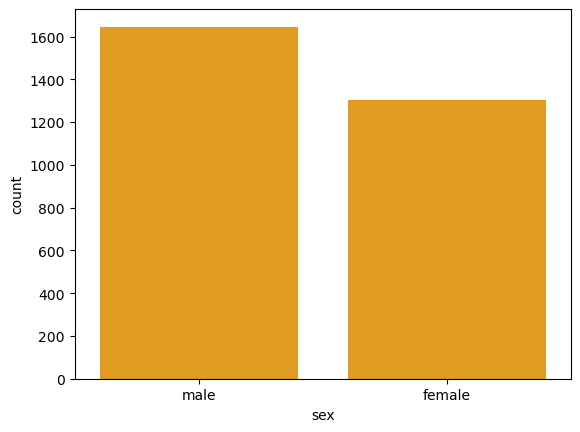

In [38]:
sns.countplot(x=df["sex"], color = "orange")

<Axes: xlabel='smoker', ylabel='count'>

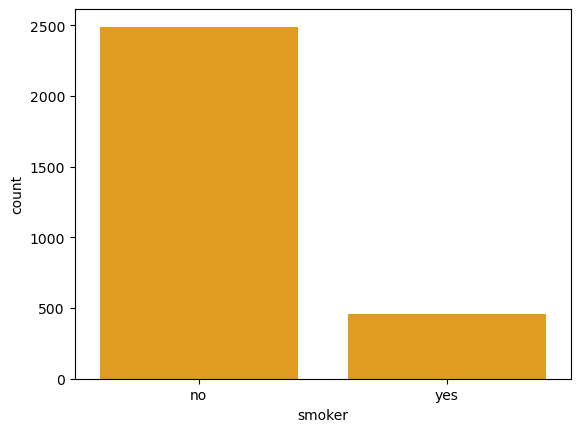

In [39]:
sns.countplot(x=df["smoker"], color = "orange")

<Axes: xlabel='region', ylabel='count'>

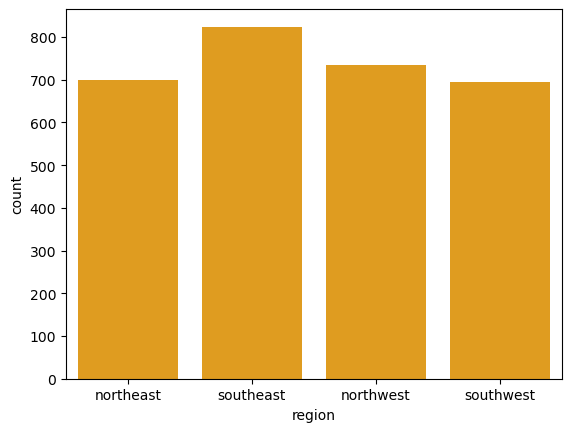

In [40]:
sns.countplot(x=df["region"], color = "orange")

<Axes: xlabel='children', ylabel='count'>

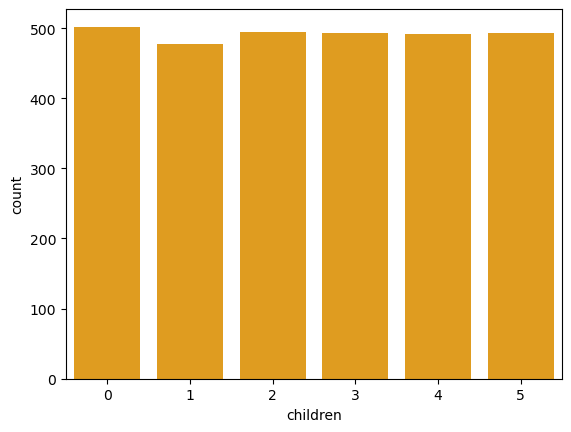

In [41]:
sns.countplot(x=df["children"], color = "orange")

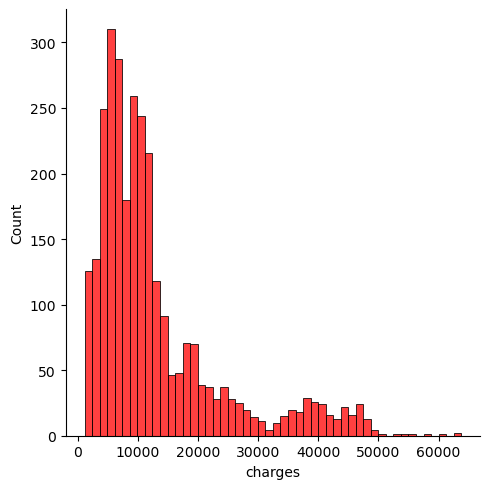

In [42]:
sns.displot(df["charges"],color = "RED")

<Axes: xlabel='age', ylabel='charges'>

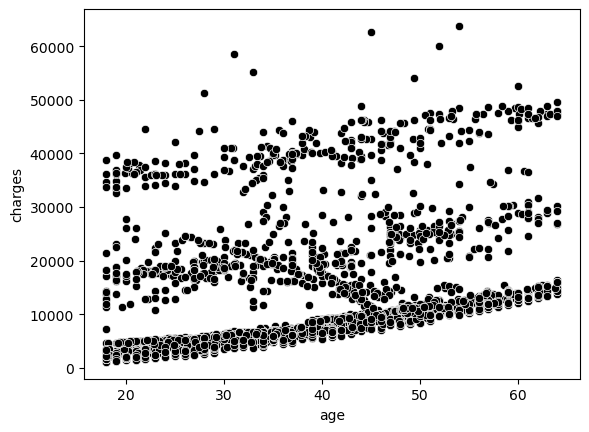

In [43]:
sns.scatterplot(x=df["age"], y=df["charges"], color = "black")

<Axes: xlabel='age', ylabel='charges'>

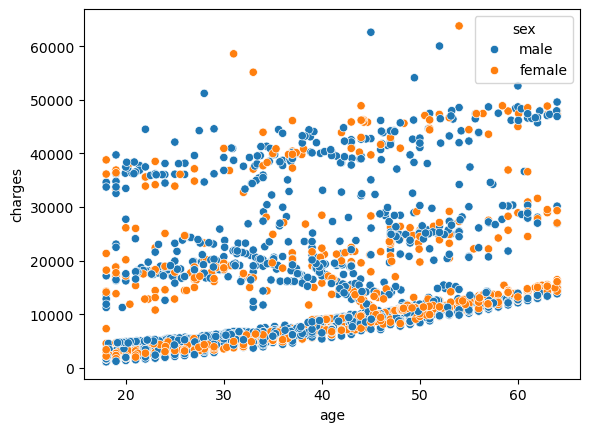

In [44]:
sns.scatterplot(x=df["age"], y=df["charges"], hue = df["sex"], color = "black")

<Axes: xlabel='bmi', ylabel='charges'>

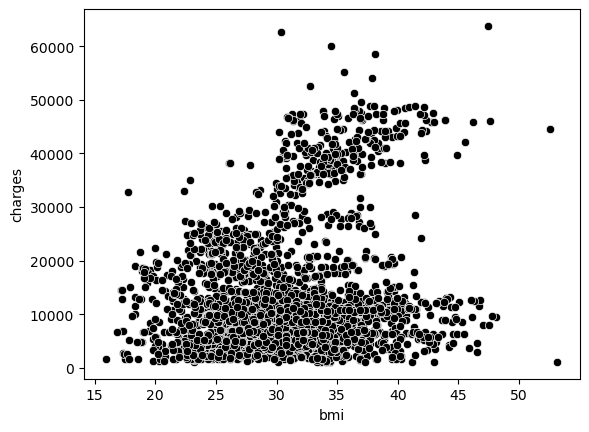

In [45]:
sns.scatterplot(x=df["bmi"], y=df["charges"], color = "black")

<Axes: xlabel='bmi', ylabel='charges'>

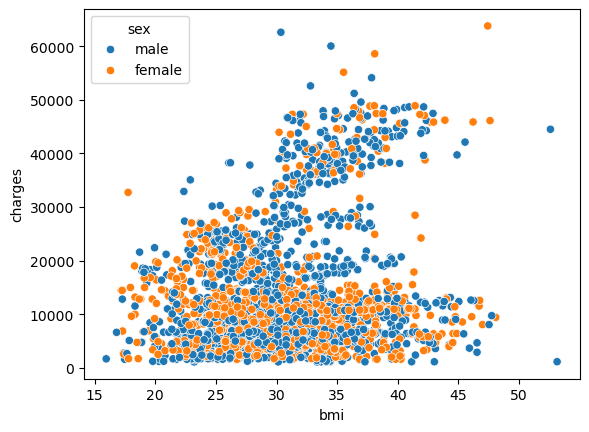

In [46]:
sns.scatterplot(x=df["bmi"], y=df["charges"], hue = df["sex"], color = "black")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_16884\1586113648.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.countplot(x=df["sex"], hue = df["region"], color = "black")


<Axes: xlabel='sex', ylabel='count'>

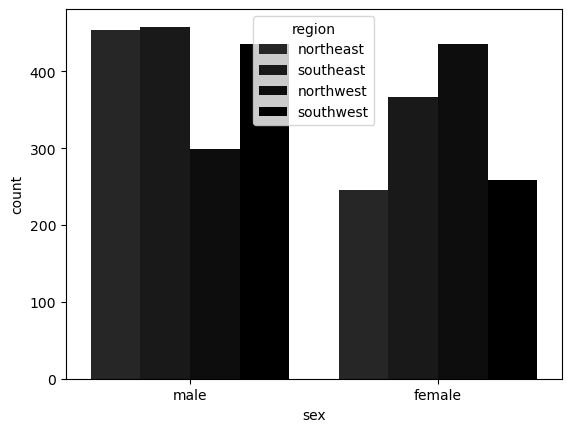

In [47]:
sns.countplot(x=df["sex"], hue = df["region"], color = "black")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_16884\3539284847.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.countplot(x=df["smoker"], hue = df["region"], color = "black")


<Axes: xlabel='smoker', ylabel='count'>

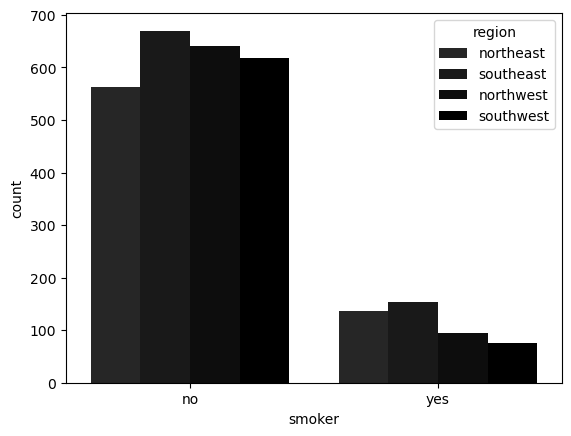

In [48]:
sns.countplot(x=df["smoker"], hue = df["region"], color = "black")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_16884\3239907369.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.countplot(x=df["children"], hue = df["region"], color = "black")


<Axes: xlabel='children', ylabel='count'>

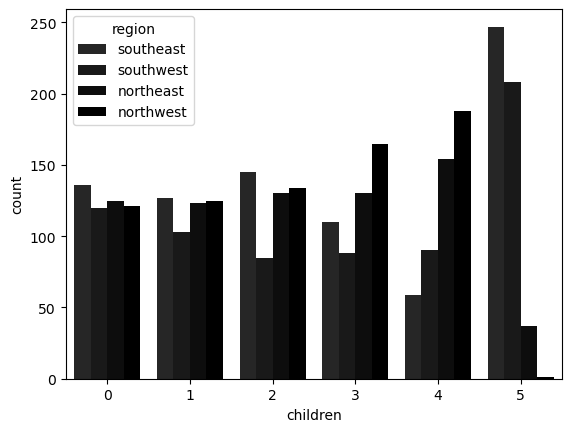

In [49]:
sns.countplot(x=df["children"], hue = df["region"], color = "black")

### checking and handling of outliers


In [50]:
def checking_and_handling_of_outliers(col):
    print(f"Checking and Handling of Outliers for {col}")
    sns.boxplot(df[col], color = "pink")

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3-q1

    lowertail = q1-1.5*iqr
    uppertail = q3+1.5*iqr

    print("-"*60)
    print(f"LowerTail = {lowertail}")
    print(f"UpperTail = {uppertail}")
    print("-"*60)

    outliers = df[(df[col]<lowertail) | (df[col]>uppertail)]

    if len(outliers) == 0 :
        print("No Outliers")
    else:
        print(outliers)

    # handling of outliers
    df.loc[df[col]<lowertail, col] = lowertail
    df.loc[df[col]>uppertail, col] = uppertail
    

Checking and Handling of Outliers for bmi
------------------------------------------------------------
LowerTail = 15.649369279312017
UpperTail = 45.16382883766588
------------------------------------------------------------
            age     sex        bmi smoker     region  children       charges
41    47.000000  female  46.986496     no  southeast         1   8083.178229
279   46.000000  female  48.070000     no  northeast         2   9432.925300
316   22.000000    male  52.580000    yes  southeast         1  44501.398200
448   47.000000  female  45.320000     no  southeast         1   8569.861800
539   25.000000    male  45.540000    yes  southeast         2  42112.235600
755   50.000000  female  46.090000     no  southeast         1   9549.565100
852   18.000000    male  53.130000     no  southeast         0   1163.462700
1032  26.000000    male  46.530000     no  southeast         1   2927.064700
1095  54.000000  female  46.700000     no  southwest         2  11538.421000
1146 

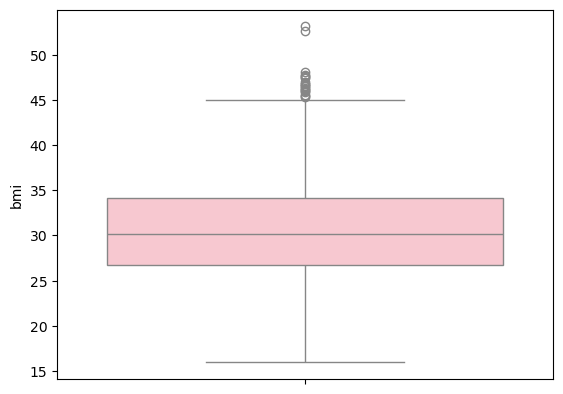

In [51]:
checking_and_handling_of_outliers("bmi")

Checking and Handling of Outliers for age
------------------------------------------------------------
LowerTail = -0.33883940797464973
UpperTail = 77.89806567995775
------------------------------------------------------------
No Outliers


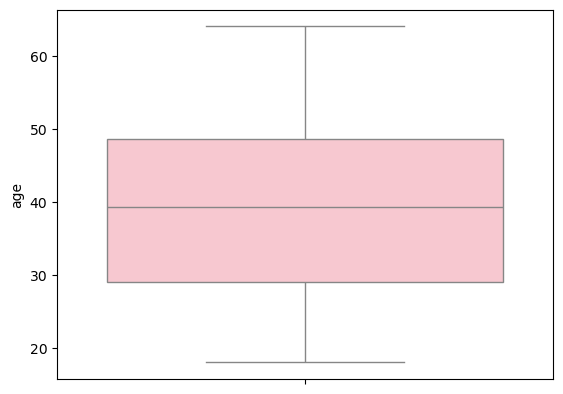

In [52]:
checking_and_handling_of_outliers("age")

#### Encoding


In [53]:
df.dtypes

age         float64
sex          object
bmi         float64
smoker       object
region       object
children      int64
charges     float64
dtype: object

In [54]:
le = LabelEncoder()
df["Gender"] = pd.DataFrame(le.fit_transform(df["sex"]))
df["smoker"] = pd.DataFrame(le.fit_transform(df["smoker"]))

In [55]:
df.dtypes

age         float64
sex          object
bmi         float64
smoker      float64
region       object
children      int64
charges     float64
Gender      float64
dtype: object

In [56]:
df.drop("sex", axis = 1, inplace=True)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2951 entries, 0 to 2951
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2951 non-null   float64
 1   bmi       2951 non-null   float64
 2   smoker    2950 non-null   float64
 3   region    2951 non-null   object 
 4   children  2951 non-null   int64  
 5   charges   2951 non-null   float64
 6   Gender    2950 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 184.4+ KB


In [58]:
df1 = pd.concat([df, pd.get_dummies(df["region"])], axis = 1 )

In [59]:
df1.drop("region", axis =1, inplace=True)

In [60]:
df1

,age,bmi,smoker,children,charges,Gender,northeast,northwest,southeast,southwest
0,21.000000,25.745000,0.0,2,3279.868550,1.0,True,False,False,False
1,36.976978,25.744165,1.0,3,21454.494239,0.0,False,False,True,False
2,18.000000,30.030000,0.0,1,1720.353700,1.0,False,False,True,False
3,37.000000,30.676891,0.0,3,6801.437542,1.0,True,False,False,False
4,58.000000,32.010000,0.0,1,11946.625900,1.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
2947,43.000000,35.531966,0.0,2,18989.365540,1.0,False,False,True,False
2948,31.374148,28.278549,0.0,4,21806.181609,0.0,True,False,False,False
2949,50.370750,26.766297,0.0,4,11355.817586,0.0,False,True,False,False
2950,49.201678,31.396840,1.0,4,11185.914056,1.0,False,True,False,False


In [61]:
df1.isna().sum()

age          0
bmi          0
smoker       1
children     0
charges      0
Gender       1
northeast    0
northwest    0
southeast    0
southwest    0
dtype: int64

In [62]:
df1.dropna(inplace=True)

In [63]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2950 entries, 0 to 2950
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        2950 non-null   float64
 1   bmi        2950 non-null   float64
 2   smoker     2950 non-null   float64
 3   children   2950 non-null   int64  
 4   charges    2950 non-null   float64
 5   Gender     2950 non-null   float64
 6   northeast  2950 non-null   bool   
 7   northwest  2950 non-null   bool   
 8   southeast  2950 non-null   bool   
 9   southwest  2950 non-null   bool   
dtypes: bool(4), float64(5), int64(1)
memory usage: 172.9 KB


In [64]:
### multivariate analysis
df1.corr()

,age,bmi,smoker,children,charges,Gender,northeast,northwest,southeast,southwest
age,1.000000,0.144587,0.023090,-0.054153,0.308325,-0.129099,-0.016677,0.100823,0.051115,-0.140184
bmi,0.144587,1.000000,0.018589,-0.024213,0.207185,-0.021301,-0.038519,0.017901,0.067997,-0.051584
smoker,0.023090,0.018589,1.000000,-0.114199,0.561792,0.074773,0.041202,-0.031749,0.040018,-0.051299
children,-0.054153,-0.024213,-0.114199,1.000000,-0.075482,0.091560,-0.080714,-0.086940,0.069879,0.095659
charges,0.308325,0.207185,0.561792,-0.075482,1.000000,0.069351,0.115387,-0.046314,0.054389,-0.126063
Gender,-0.129099,-0.021301,0.074773,0.091560,0.069351,1.000000,0.080233,-0.144537,-0.002684,0.069762
northeast,-0.016677,-0.038519,0.041202,-0.080714,0.115387,0.080233,1.000000,-0.320711,-0.346923,-0.308782
northwest,0.100823,0.017901,-0.031749,-0.086940,-0.046314,-0.144537,-0.320711,1.000000,-0.358299,-0.318907
southeast,0.051115,0.067997,0.040018,0.069879,0.054389,-0.002684,-0.346923,-0.358299,1.000000,-0.344971
southwest,-0.140184,-0.051584,-0.051299,0.095659,-0.126063,0.069762,-0.308782,-0.318907,-0.344971,1.000000


### Multivariate Analysis / Feature Selection - Filter Method


<Axes: >

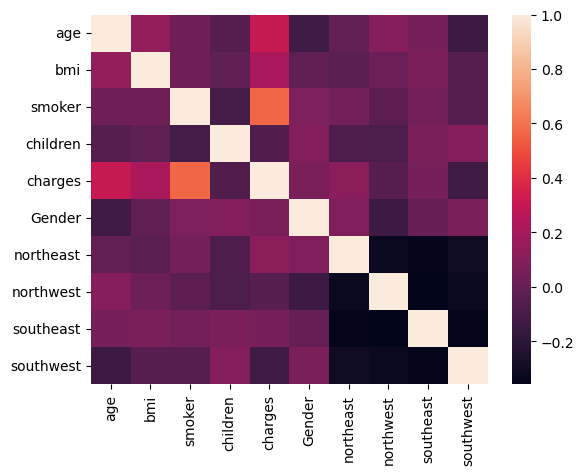

In [65]:
sns.heatmap(df1.corr())

<Axes: >

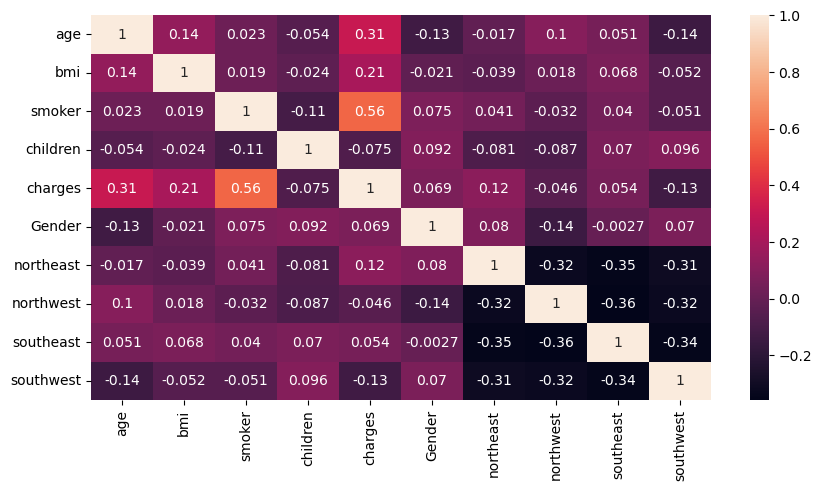

In [66]:
plt.figure(figsize=(10,5))
sns.heatmap(df1.corr(), annot = True)

#### 1. Linearity (before model training)


<Axes: >

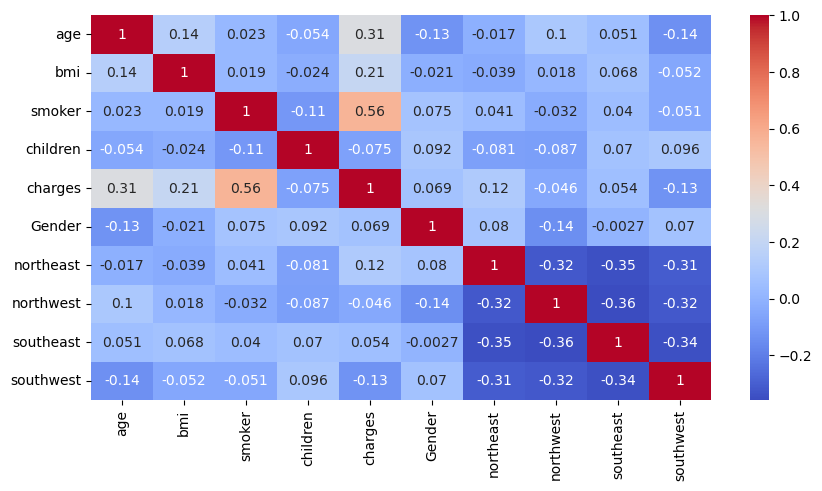

In [67]:
plt.figure(figsize=(10,5))
sns.heatmap(df1.corr(), annot = True, cmap = "coolwarm")

<Axes: >

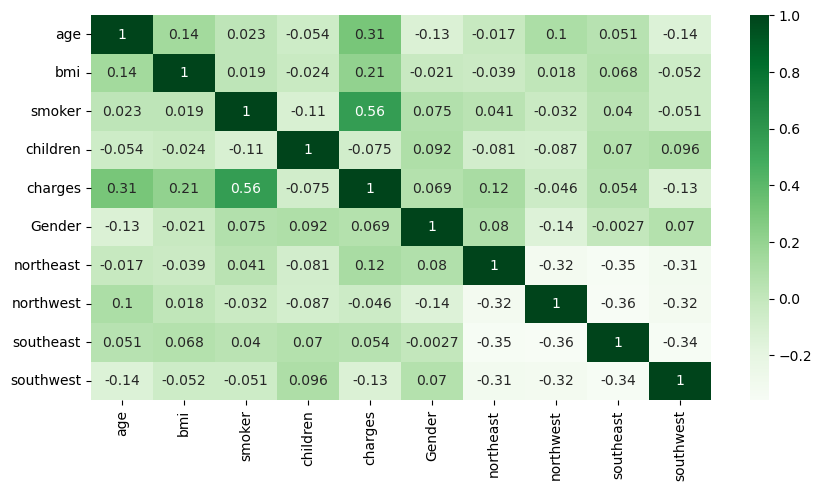

In [68]:
plt.figure(figsize=(10,5))
sns.heatmap(df1.corr(), annot = True, cmap = "Greens")

<Axes: >

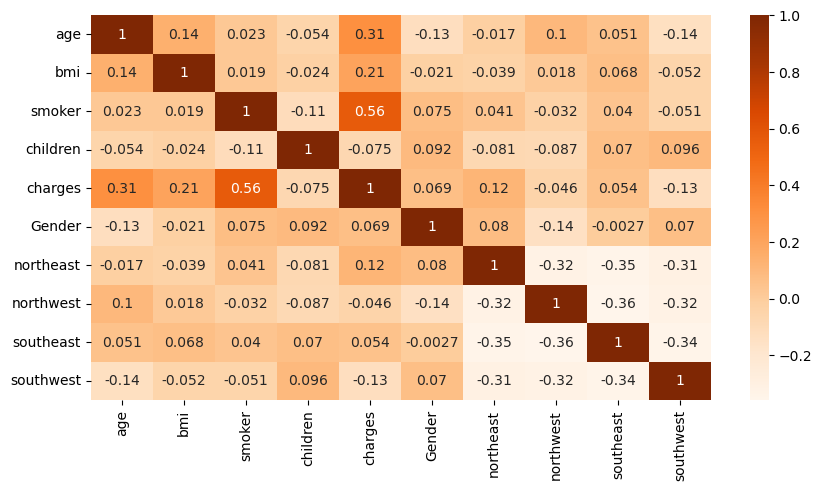

In [69]:
plt.figure(figsize=(10,5))
sns.heatmap(df1.corr(), annot = True, cmap = "Oranges")

<Axes: >

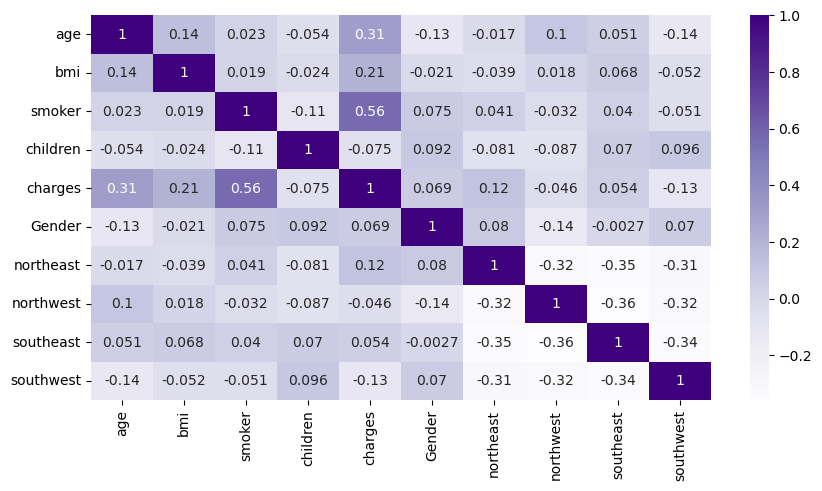

In [70]:
plt.figure(figsize=(10,5))
sns.heatmap(df1.corr(), annot = True, cmap = "Purples")

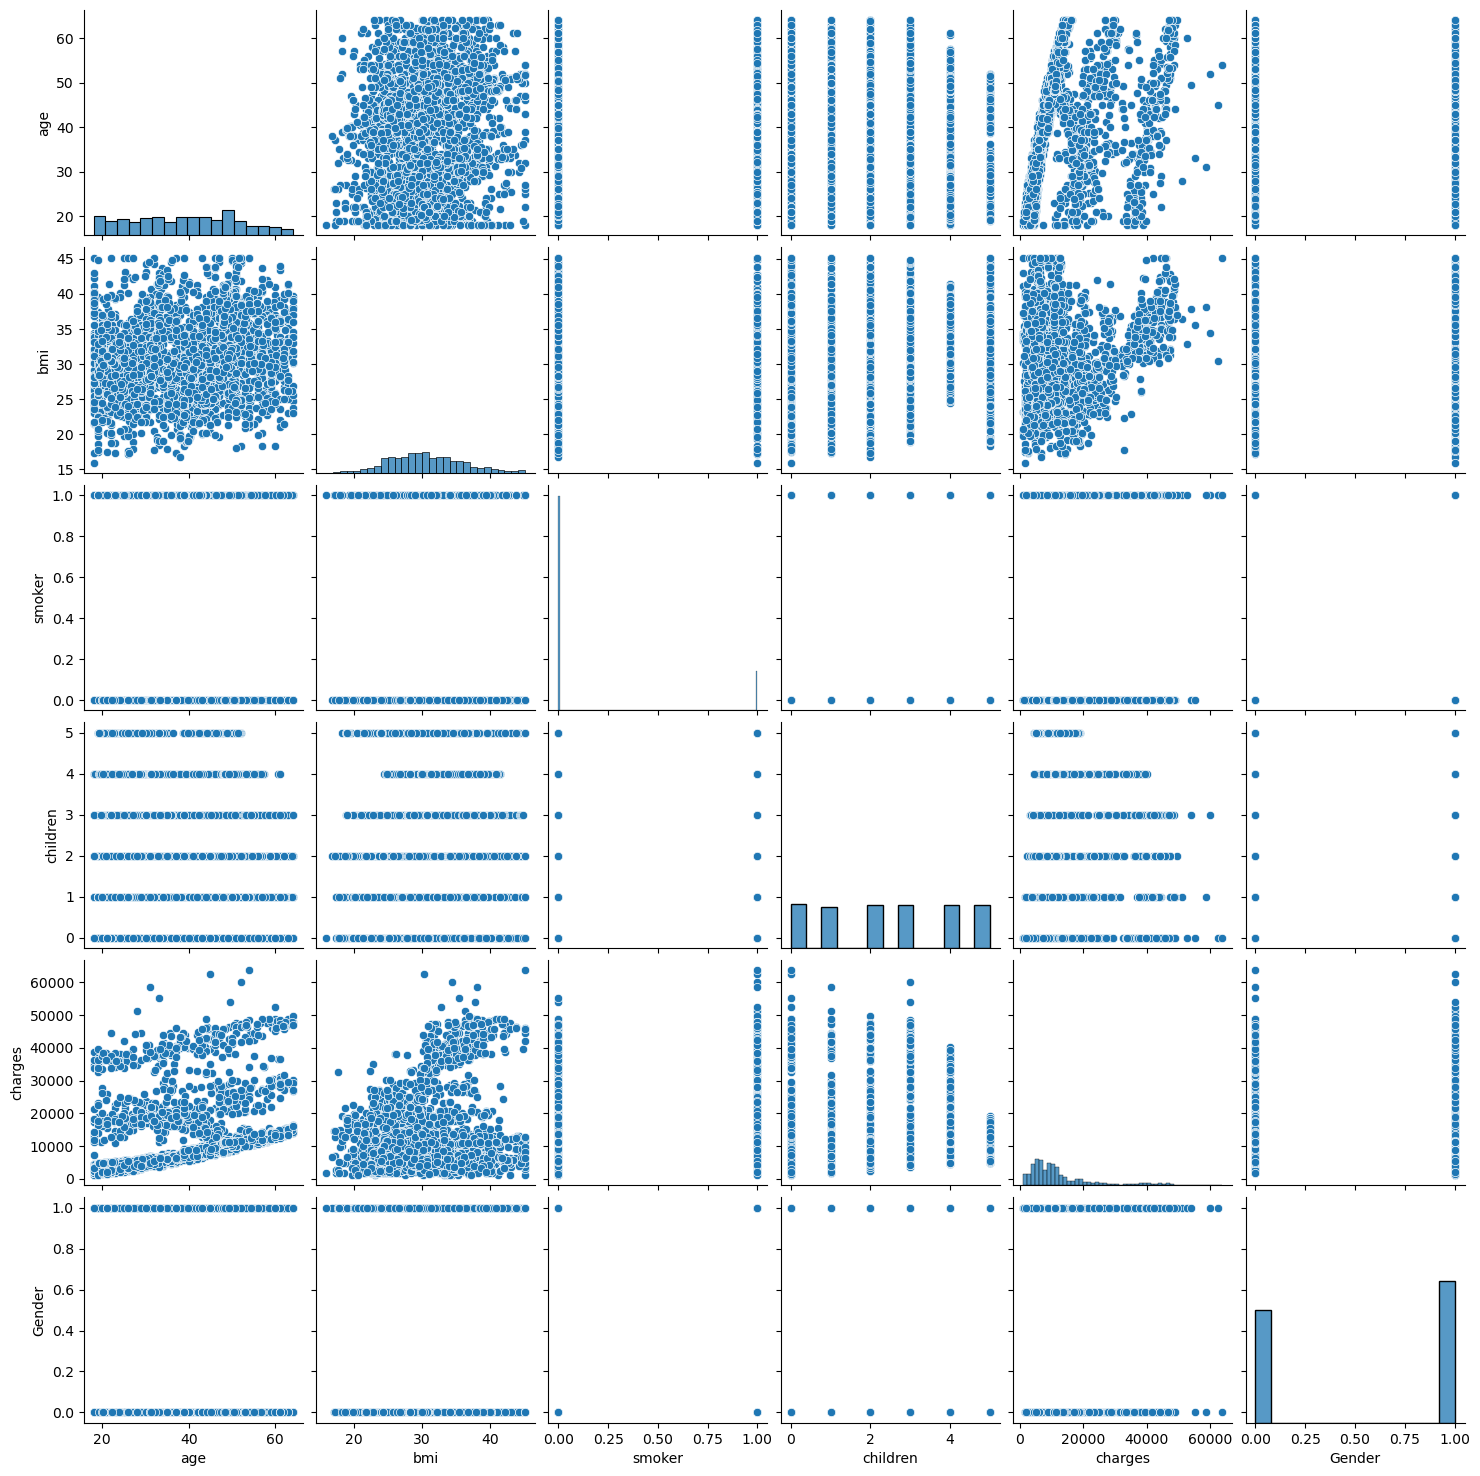

In [71]:
sns.pairplot(df)

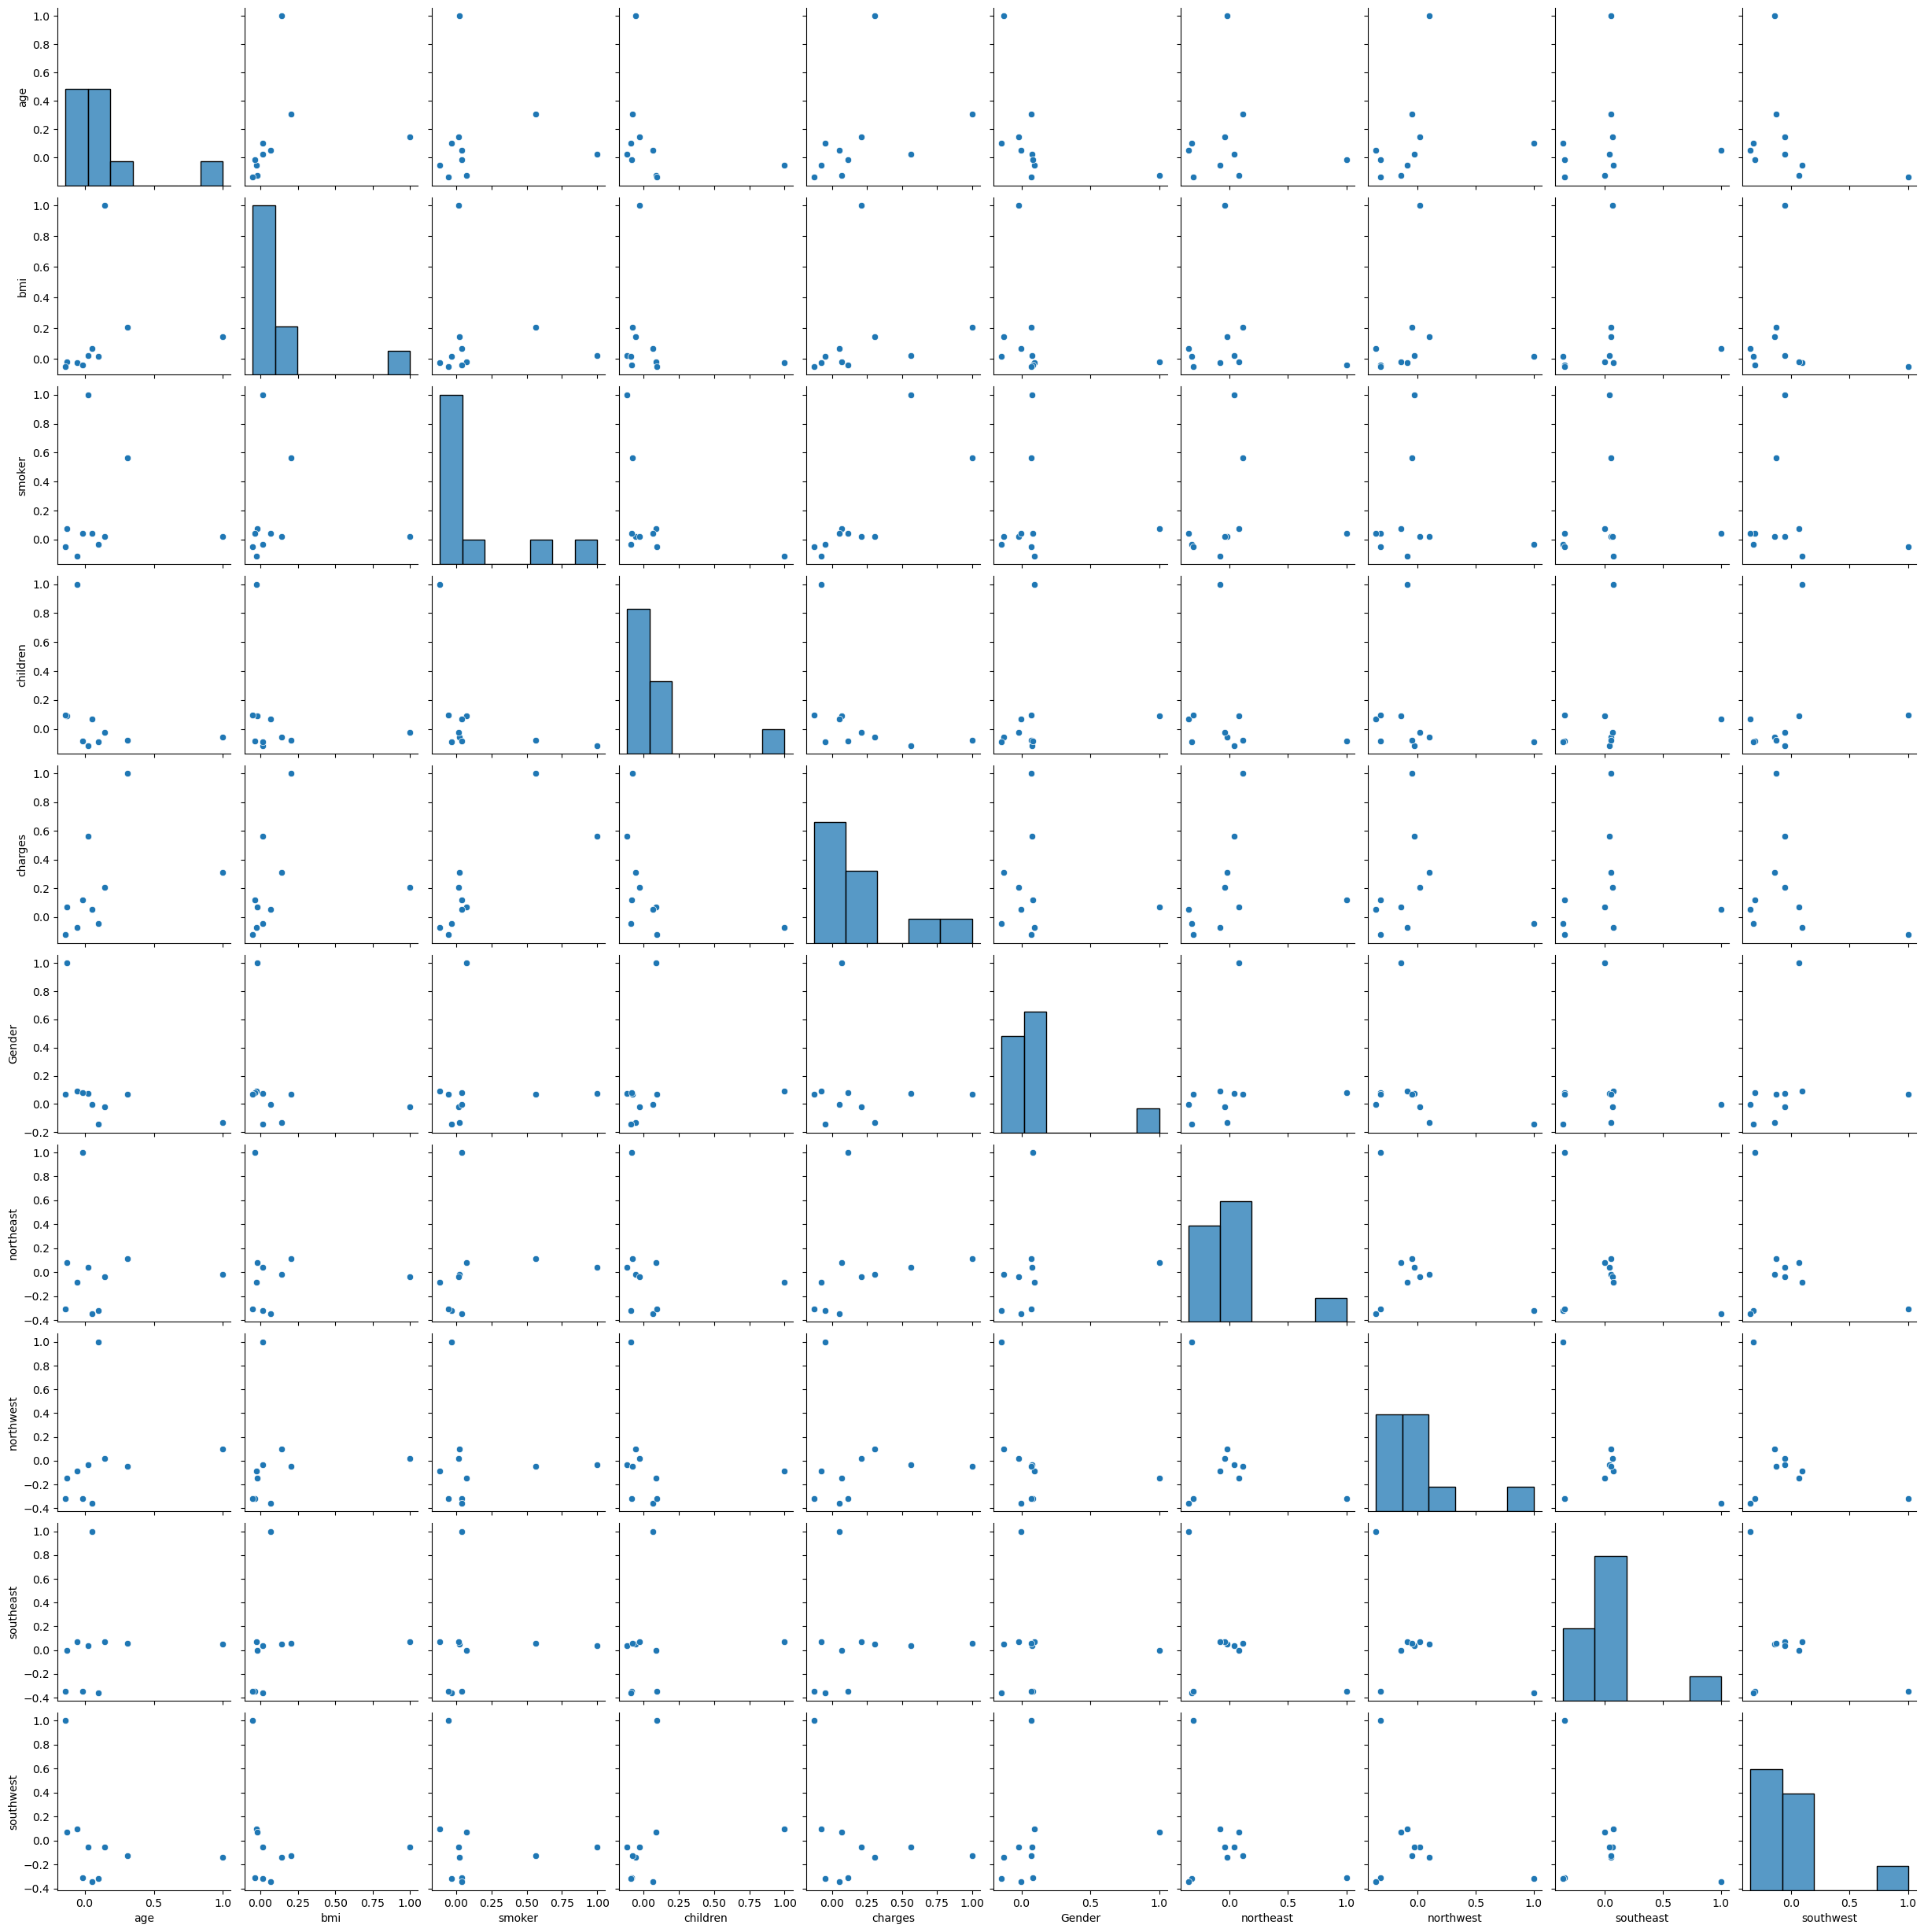

In [72]:
sns.pairplot(df1.corr())

#### Assumption 2. No Multicolinearity/ Independance (before model training)


In [73]:
df["region"].unique()

array(['northeast', 'southeast', 'northwest', 'southwest'], dtype=object)

In [74]:
df["region"] = df["region"].replace({'northeast':1, 'southeast':2, 'northwest':3, 'southwest':4})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_16884\1491668147.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["region"] = df["region"].replace({'northeast':1, 'southeast':2, 'northwest':3, 'southwest':4})


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2951 entries, 0 to 2951
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2951 non-null   float64
 1   bmi       2951 non-null   float64
 2   smoker    2950 non-null   float64
 3   region    2951 non-null   int64  
 4   children  2951 non-null   int64  
 5   charges   2951 non-null   float64
 6   Gender    2950 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 184.4 KB


#### Assumption 2. No Multicolinearity/ Independance (before model training)


In [76]:
independant_features_df = df.drop("charges", axis = 1)
independant_features_df

,age,bmi,smoker,region,children,Gender
0,21.000000,25.745000,0.0,1,2,1.0
1,36.976978,25.744165,1.0,2,3,0.0
2,18.000000,30.030000,0.0,2,1,1.0
3,37.000000,30.676891,0.0,1,3,1.0
4,58.000000,32.010000,0.0,2,1,1.0
...,...,...,...,...,...,...
2947,43.000000,35.531966,0.0,2,2,1.0
2948,31.374148,28.278549,0.0,1,4,0.0
2949,50.370750,26.766297,0.0,3,4,0.0
2950,49.201678,31.396840,1.0,3,4,1.0


In [77]:
independant_features_df.dropna(inplace=True)

In [78]:
vif_df = pd.DataFrame()
vif_df["Independent Features"] = independant_features_df.columns

In [79]:
vif_df

,Independent Features
0,age
1,bmi
2,smoker
3,region
4,children
5,Gender


In [80]:
independant_features_df

,age,bmi,smoker,region,children,Gender
0,21.000000,25.745000,0.0,1,2,1.0
1,36.976978,25.744165,1.0,2,3,0.0
2,18.000000,30.030000,0.0,2,1,1.0
3,37.000000,30.676891,0.0,1,3,1.0
4,58.000000,32.010000,0.0,2,1,1.0
...,...,...,...,...,...,...
2946,21.000000,39.490000,1.0,2,0,1.0
2947,43.000000,35.531966,0.0,2,2,1.0
2948,31.374148,28.278549,0.0,1,4,0.0
2949,50.370750,26.766297,0.0,3,4,0.0


In [81]:
independant_features_df.dtypes

age         float64
bmi         float64
smoker      float64
region        int64
children      int64
Gender      float64
dtype: object

In [82]:
a = independant_features_df.shape[1]
a

6

In [83]:
vif_list = []

for i in range(len(independant_features_df.columns)):
    vif = variance_inflation_factor(independant_features_df.to_numpy(), i)
    vif_list.append(vif)
vif_list

[np.float64(9.931945465655733),
 np.float64(14.981039579103868),
 np.float64(1.2091320373636438),
 np.float64(5.471949333243566),
 np.float64(3.0908759610710614),
 np.float64(2.2374239287217303)]

In [84]:
vif_df["VIF"] = vif_list

In [85]:
vif_df

,Independent Features,VIF
0,age,9.931945
1,bmi,14.981040
2,smoker,1.209132
3,region,5.471949
4,children,3.090876
5,Gender,2.237424


In [86]:
df1

,age,bmi,smoker,children,charges,Gender,northeast,northwest,southeast,southwest
0,21.000000,25.745000,0.0,2,3279.868550,1.0,True,False,False,False
1,36.976978,25.744165,1.0,3,21454.494239,0.0,False,False,True,False
2,18.000000,30.030000,0.0,1,1720.353700,1.0,False,False,True,False
3,37.000000,30.676891,0.0,3,6801.437542,1.0,True,False,False,False
4,58.000000,32.010000,0.0,1,11946.625900,1.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
2946,21.000000,39.490000,1.0,0,2026.974100,1.0,False,False,True,False
2947,43.000000,35.531966,0.0,2,18989.365540,1.0,False,False,True,False
2948,31.374148,28.278549,0.0,4,21806.181609,0.0,True,False,False,False
2949,50.370750,26.766297,0.0,4,11355.817586,0.0,False,True,False,False


In [87]:
df1.shape

(2950, 10)

In [88]:
x = df1.drop("charges", axis = 1) # independant features
y = df1["charges"] # targetcolumn

In [89]:
x.shape

(2950, 9)

#### train test split


In [90]:
xtrain, xtest, ytrain,ytest = train_test_split(x,y, test_size=0.2, random_state=11)

In [91]:
xtrain.shape

(2360, 9)

In [92]:
ytrain # yactual

597     47928.030000
36       9051.900035
1085     5840.481587
1811    11411.685000
1940     6088.775823
            ...     
1697     6341.793391
332      6496.886000
1293    12638.195000
1104    11658.115050
1945    25026.423277
Name: charges, Length: 2360, dtype: float64

In [93]:
xtest.shape

(590, 9)

In [94]:
ytest

2853     9414.920000
2621     9104.377344
1511    10879.172843
2612    19480.237416
2256    22493.659640
            ...     
1238    11289.109250
1479     6335.768145
1700    12925.886000
464      4783.242863
261     17178.682400
Name: charges, Length: 590, dtype: float64

### Model Training + Evaluation


#### aloritham 1 : LinearRegression


In [95]:
lin_reg = LinearRegression()
lin_reg_model = lin_reg.fit(xtrain, ytrain)
lin_reg_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [96]:
ytrain_pred = lin_reg_model.predict(xtrain)
ytest_pred = lin_reg_model.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 64468285.42644933
--------------------------------------------------
Mean Absolute Error = 5303.186875752504
--------------------------------------------------
Root Mean Squared Error = 8029.214496228715
--------------------------------------------------
R2 Score = 0.4482662281368547
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 63909378.60973882
--------------------------------------------------
Mean Absolute Error = 5421.190375531781
--------------------------------------------------
Root Mean Squared Error = 7994.334156747441
--------------------------------------------------
R2 Score = 0.4482662281368547
--------------------------------------------------


### Algoritham Knn


In [97]:
knn=KNeighborsRegressor()
knn_module= knn.fit(xtrain,ytrain)
knn_module

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [98]:
ytrain_pred = knn_module.predict(xtrain)
ytest_pred = knn_module.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 51126718.94635565
--------------------------------------------------
Mean Absolute Error = 4073.714497473799
--------------------------------------------------
Root Mean Squared Error = 7150.29502512698
--------------------------------------------------
R2 Score = 0.5624462896652943
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 88015026.83672403
--------------------------------------------------
Mean Absolute Error = 5710.769499240894
--------------------------------------------------
Root Mean Squared Error = 9381.632418546573
--------------------------------------------------
R2 Score = 0.5624462896652943
--------------------------------------------------


### alogoritham 3 dicision tree


In [99]:
dt = DecisionTreeRegressor()
dt_model = dt.fit(xtrain, ytrain)
dt_model


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [100]:
ytrain_pred = dt_model.predict(xtrain)
ytest_pred = dt_model.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 77675.65509450213
--------------------------------------------------
Mean Absolute Error = 8.316973907010222
--------------------------------------------------
Root Mean Squared Error = 278.70352544326045
--------------------------------------------------
R2 Score = 0.9993352346524537
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 82632087.88885789
--------------------------------------------------
Mean Absolute Error = 4095.5132556787817
--------------------------------------------------
Root Mean Squared Error = 9090.219353176131
--------------------------------------------------
R2 Score = 0.9993352346524537
--------------------------------------------------


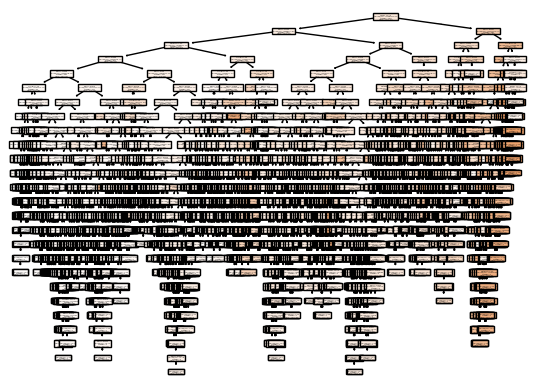

In [101]:
plot_tree(dt_model, feature_names=x.columns, filled=True)
plt.show()

### Algorithm 4: random Forest


In [102]:
rf = RandomForestRegressor()
rf_model = rf.fit(xtrain,ytrain)
rf_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [103]:
ytrain_pred = rf_model.predict(xtrain)
ytest_pred = rf_model.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 7177024.539083743
--------------------------------------------------
Mean Absolute Error = 1404.649765582857
--------------------------------------------------
Root Mean Squared Error = 2678.9969277854243
--------------------------------------------------
R2 Score = 0.9385774448085688
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 44718056.032506645
--------------------------------------------------
Mean Absolute Error = 3740.158109230709
--------------------------------------------------
Root Mean Squared Error = 6687.156049660172
--------------------------------------------------
R2 Score = 0.9385774448085688
--------------------------------------------------


### Algoritham 5 : AdaBoostRegressor


In [104]:
AD=AdaBoostRegressor()
AD_module = AD.fit(xtrain, ytrain)
AD_module

,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,None


In [105]:
ytrain_pred = AD_module.predict(xtrain)
ytest_pred = AD_module.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 106960595.05481088
--------------------------------------------------
Mean Absolute Error = 9226.309399638374
--------------------------------------------------
Root Mean Squared Error = 10342.175547476018
--------------------------------------------------
R2 Score = 0.0846076926049939
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 111020775.4910553
--------------------------------------------------
Mean Absolute Error = 9316.94018216308
--------------------------------------------------
Root Mean Squared Error = 10536.63966789485
--------------------------------------------------
R2 Score = 0.0846076926049939
--------------------------------------------------


### Algoritham 6 : Gradieant boosting Regeressor


In [106]:
gb = GradientBoostingRegressor()
gb_module = gb.fit(xtrain,ytrain)
gb_module

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [107]:
ytrain_pred = gb_module.predict(xtrain)
ytest_pred = gb_module.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 38725860.61955363
--------------------------------------------------
Mean Absolute Error = 3747.4253291092195
--------------------------------------------------
Root Mean Squared Error = 6223.010575240382
--------------------------------------------------
R2 Score = 0.6685755638305402
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 45014467.83381435
--------------------------------------------------
Mean Absolute Error = 4113.58885365798
--------------------------------------------------
Root Mean Squared Error = 6709.28221450062
--------------------------------------------------
R2 Score = 0.6685755638305402
--------------------------------------------------


### Algoritham 7 :XGBRegressor


In [108]:
xg= XGBRegressor()
xg_module = xg.fit(xtrain, ytrain)
xg_module

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [109]:
ytrain_pred = xg_module.predict(xtrain)
ytest_pred = xg_module.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 3532067.101501936
--------------------------------------------------
Mean Absolute Error = 1130.8956136808213
--------------------------------------------------
Root Mean Squared Error = 1879.3794458549173
--------------------------------------------------
R2 Score = 0.969771792572199
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 58603383.79300482
--------------------------------------------------
Mean Absolute Error = 4540.00008388184
--------------------------------------------------
Root Mean Squared Error = 7655.284697057636
--------------------------------------------------
R2 Score = 0.969771792572199
--------------------------------------------------


### Algoritham 8: SVR


In [110]:
svm = SVR()
svm_module = svm.fit(xtrain,ytrain)
svm_module

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [111]:
ytrain_pred = svm_module.predict(xtrain)
ytest_pred = svm_module.predict(xtest)
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(ytrain, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(ytrain, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(ytrain, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)


print("Model Evaluation for Testing Data")
print("-"* 50)

mse = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)
      
mae = mean_absolute_error(ytest, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2score = r2_score(ytest, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 127788038.51678766
--------------------------------------------------
Mean Absolute Error = 6969.097148644414
--------------------------------------------------
Root Mean Squared Error = 11304.337155127127
--------------------------------------------------
R2 Score = -0.09363815127824338
--------------------------------------------------
Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 123529601.4292926
--------------------------------------------------
Mean Absolute Error = 7077.906281938173
--------------------------------------------------
Root Mean Squared Error = 11114.387136918194
--------------------------------------------------
R2 Score = -0.09363815127824338
--------------------------------------------------


### best model save in .pkl


In [128]:
import pickle

In [131]:
with open("FinalModel_Med.pkl", "wb") as f:
    pickle.dump(xg_module, f)

In [135]:
with open("FinalModel_Med.pkl", "rb") as f:
    FinalModel = pickle.load(f)

FinalModel

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [142]:
df.iloc[2852:2853,:]

,age,bmi,smoker,region,children,charges,Gender
2853,46.0,30.8,1.0,4,3,9414.92,0.0


In [116]:
xtest.head(1)

,age,bmi,smoker,children,Gender,northeast,northwest,southeast,southwest
2853,46.0,30.8,1.0,3,0.0,False,False,False,True


In [117]:
ytest.head(1)

2853    9414.92
Name: charges, dtype: float64

### function to make predictions on new data


In [143]:
def MyPrediction(age, bmi, smoker,children, Gender, region):
        input_data = pd.DataFrame({
        "age" : [age],
        "bmi" : [bmi],
        "smoker" : 1 if smoker == "yes" else 0,
        "children"  : [children],
        "Gender" : 1 if Gender == "male" else 0,
        "northeast" : True if region  == "northeast" else 0,
        "northwest" : True if region  == "northwest" else 0,
        "southeast" : True if region  == "southeast" else 0,
        "southwest" : True if region  == "southwest" else 0})

        print(input_data)

        with open("FinalModel_Med.pkl", "rb") as f:
            FinalModel = pickle.load(f)

        charges = FinalModel.predict(input_data)

        print(f"Medical Insurance Charges = Rs. {np.round(charges[0], 2)}")
        
         
        
        
    

In [157]:
MyPrediction(60,120,'Yes',2,'Male','southwest')

   age  bmi  smoker  children  Gender  northeast  northwest  southeast  \
0   60  120       0         2       0          0          0          0   

   southwest  
0       True  
Medical Insurance Charges = Rs. 22660.240234375
